# 02. Liquidity and Market Depth Dynamics

Giá không chỉ được quyết định bởi order.

Mức độ thay đổi của giá phụ thuộc vào cấu trúc thanh khoản.

Notebook này khám phá:

- Liquidity thực sự là gì
- Depth kiểm soát impact như thế nào
- Tính phi tuyến của risk
- Liquidity evaporation trong khủng hoảng
- Cơ chế feedback giữa volatility và liquidity

Nếu 01 nói về cơ học hình thành giá, 02 nói về độ ổn định của hệ thống.

## 1. Liquidity Is Structural

Volume là quá khứ.

Liquidity là khả năng hấp thụ giao dịch tại thời điểm hiện tại
mà không gây biến động lớn.

Liquidity gồm:

- Depth (độ sâu)
- Spread
- Khả năng refill

Liquidity là bộ giảm xóc của thị trường.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.structure.liquidity import LiquidityModel, LiquidityShockModel

## 2. Impact vs Liquidity Depth

Giữ nguyên order size.
Thay đổi depth.
Quan sát impact.

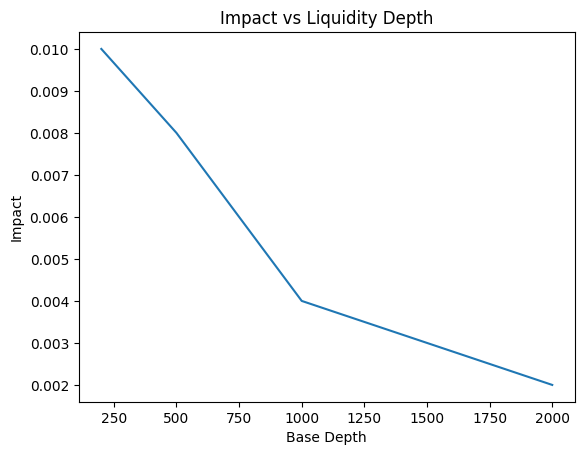

In [2]:
def simulate_depth_effect(depth, order_size=400):
    model = LiquidityModel(base_depth=depth)
    result = model.execute_trade(order_size)
    return result["impact"]

depths = [200, 500, 1000, 2000]
impacts = [simulate_depth_effect(d) for d in depths]

plt.plot(depths, impacts)
plt.xlabel("Base Depth")
plt.ylabel("Impact")
plt.title("Impact vs Liquidity Depth")
plt.show()

### Structural Interpretation

Impact giảm theo hàm nghịch đảo của liquidity depth.

Điều này xác nhận rằng:
price sensitivity không phải hằng số,
mà phụ thuộc vào cấu trúc thanh khoản.

Liquidity đóng vai trò như bộ giảm xóc của thị trường.

Khi depth tăng gấp đôi,
impact giảm gần một nửa.

Stability là hàm của liquidity.

### Why Does the Curve Have a Kink?

Đồ thị không phải là một đường cong mượt hoàn toàn.
Nó xuất hiện một điểm gãy (kink).

Điểm gãy này không phải do lỗi toán học,
mà đến từ cấu trúc rời rạc của thanh khoản.

Trong mô hình:

$$ Impact = k × \frac{Order Size}{Depth}$$

Khi depth nhỏ hơn order size,
lệnh tiêu thụ toàn bộ liquidity khả dụng.

Tại ngưỡng này:

- Relative size ≥ 1
- Liquidity bị cạn
- Spread tăng mạnh
- Impact không còn giảm đều

Điểm gãy chính là ranh giới giữa hai regime:

1. Absorption regime
   Liquidity đủ lớn để hấp thụ order mà không gây biến động mạnh.

2. Fragility regime
   Liquidity gần cạn, hệ thống trở nên cực kỳ nhạy cảm.

Điều này phản ánh một thực tế quan trọng:

- Thị trường không phản ứng liên tục và mượt. Nó phản ứng theo từng ngưỡng cấu trúc.
- Khi vượt qua một ngưỡng liquidity, độ nhạy của giá thay đổi đột ngột.

> Đây là nguồn gốc của nonlinear risk.

## 3. Nonlinear Risk

Impact không tăng tuyến tính theo size.

Khi depth gần cạn:

- Relative size tăng nhanh
- Spread giãn
- Impact tăng mạnh

Risk không tăng tỷ lệ thuận với position size.

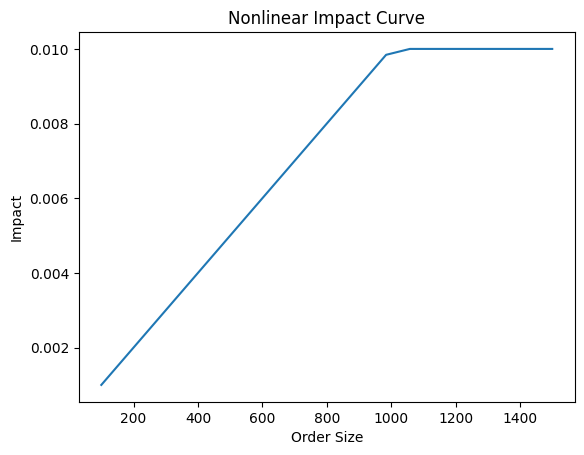

In [3]:
sizes = np.linspace(100, 1500, 20)
impacts = []

model = LiquidityModel(base_depth=1000)

for s in sizes:
    model = LiquidityModel(base_depth=1000)
    result = model.execute_trade(s)
    impacts.append(result["impact"])

plt.plot(sizes, impacts)
plt.xlabel("Order Size")
plt.ylabel("Impact")
plt.title("Nonlinear Impact Curve")
plt.show()

### Why Does the Impact Curve Flatten?

Đồ thị cho thấy hai vùng rõ ràng:

1. Vùng tăng gần tuyến tính
2. Vùng bão hòa (plateau)

#### 1. Vùng tăng ban đầu

Khi order size còn nhỏ hơn hoặc xấp xỉ liquidity khả dụng:

$$ Impact \approx k × \frac{Order Size}{Depth}$$

Trong vùng này:

- Relative size tăng dần
- Impact tăng gần tuyến tính
- Liquidity vẫn còn khả năng hấp thụ

Đây là absorption regime.

---

#### 2. Điểm gãy (kink)

Điểm gãy xuất hiện khi:

Order Size ≈ Base Depth

Tại thời điểm này:

- Relative size tiến gần 1
- Liquidity bị tiêu hao gần hết
- Hệ thống bước vào trạng thái mong manh

Điểm gãy chính là ranh giới giữa hai chế độ thị trường (regime shift).

---

#### 3. Vùng bão hòa (plateau)

Sau khi liquidity gần cạn:

- Depth không còn giảm thêm đáng kể
- Impact đạt mức tối đa của mô hình
- Đường cong phẳng lại

Điều này phản ánh giới hạn cấu trúc của hệ thống:

Không phải impact tăng vô hạn,
mà hệ thống chạm ngưỡng thanh khoản.

---

### Structural Meaning

Điểm gãy không phải là lỗi.
Nó là hệ quả của cấu trúc liquidity hữu hạn.

Khi order size tiến sát liquidity,
risk tăng nhanh.
Sau khi liquidity cạn,
thị trường bước vào trạng thái dislocation.

Nonlinear impact không chỉ là đường cong.
Nó là biểu hiện của liquidity threshold.

## 4. Liquidity Refill and Stability

Thanh khoản không cố định.
Nó có thể được tái tạo theo thời gian.

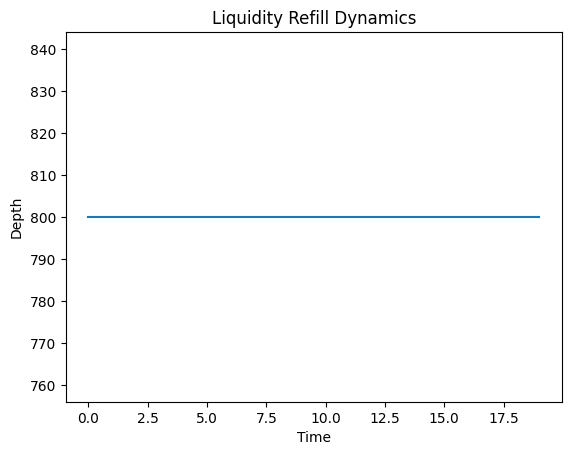

In [4]:
model = LiquidityModel(base_depth=1000)

depth_series = []

for t in range(20):
    model.execute_trade(200)
    depth_series.append(model.current_depth)
    model.refill(refill_rate=0.2)

plt.plot(depth_series)
plt.title("Liquidity Refill Dynamics")
plt.xlabel("Time")
plt.ylabel("Depth")
plt.show()

### Liquidity Resilience and Stability

Thanh khoản không cố định.
Nó liên tục bị tiêu hao và tái tạo.

Khi tốc độ tái tạo >= tốc độ tiêu hao,
thị trường ổn định.

Khi tốc độ tiêu hao vượt tốc độ tái tạo,
liquidity giảm dần và hệ thống trở nên mong manh.

Biểu đồ trên minh họa trạng thái cân bằng động.

Stability không phải vì không có shock,
mà vì hệ thống có khả năng hấp thụ và hồi phục.

## 5. Liquidity Evaporation During Crisis

Trong khủng hoảng:

- Volatility tăng
- Market maker rút thanh khoản
- Depth giảm phi tuyến

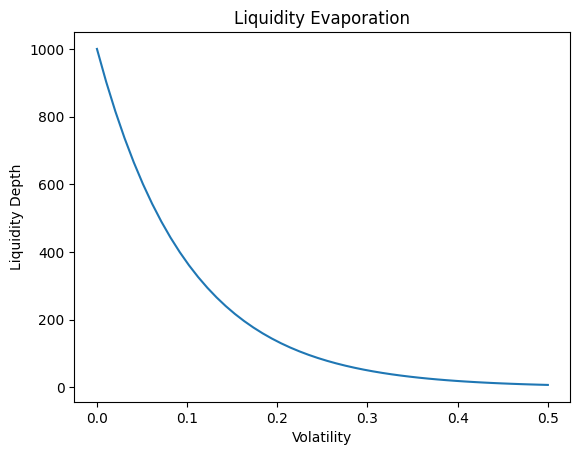

In [5]:
shock = LiquidityShockModel(base_depth=1000)

vol_series = np.linspace(0, 0.5, 50)
depth_series = []

for v in vol_series:
    shock.update(v)
    depth_series.append(shock.get_depth())

plt.plot(vol_series, depth_series)
plt.xlabel("Volatility")
plt.ylabel("Liquidity Depth")
plt.title("Liquidity Evaporation")
plt.show()

## Liquidity Evaporation: Structural Fragility Under Volatility

Biểu đồ trên cho thấy mối quan hệ giữa volatility và liquidity depth.

Depth không giảm tuyến tính.
Nó giảm theo hàm mũ.

$$
Depth = BaseDepth × e^{-k × Volatility}
$$

Điều này có nghĩa:

- Khi volatility thấp, liquidity gần như không thay đổi nhiều.
- Khi volatility vượt một ngưỡng, liquidity giảm rất nhanh.
- Hệ thống chuyển sang trạng thái mong manh.

---

### 1. Tại sao liquidity giảm khi volatility tăng?

Market maker cung cấp thanh khoản bằng cách đặt limit order.
Họ đối mặt với inventory risk và adverse selection risk.

Khi volatility tăng:

- Xác suất bị "picked off" tăng
- Sai số định giá tăng
- Risk-adjusted return giảm
- VaR và capital requirement tăng

Kết quả:
Market maker thu hẹp quy mô quote hoặc rút thanh khoản.

Liquidity không biến mất vì thị trường không có người mua.
Nó biến mất vì risk tăng vượt ngưỡng chấp nhận.

---

### 2. Exponential Decay và Tính Phi Tuyến

Hàm mũ tạo ra convexity:

Ở volatility thấp:
Depth giảm chậm.

Ở volatility cao:
Depth sụp nhanh.

Điều này quan trọng vì:

Liquidity không phản ứng tuyến tính.
Nó có threshold behavior.

Khi vượt qua một mức volatility nhất định,
hệ thống chuyển từ stable regime sang fragile regime.

---

### 3. Nonlinear Amplification

Ta có hai quan hệ:

Impact ∝ 1 / Depth
$ Depth ∝ e^{-k × Volatility} $

Suy ra:

$ Impact  ∝ e^{-k × Volatility} $

Tức là:

Một tăng nhỏ trong volatility
có thể tạo tăng lớn trong impact.

Đây là cơ chế amplification phi tuyến.

---

### 4. Feedback Loop của Crisis

Chuỗi động học:

1. Shock làm volatility tăng.
2. Liquidity giảm theo hàm mũ.
3. Impact tăng.
4. Giá biến động mạnh hơn.
5. Volatility tăng thêm.
6. Liquidity tiếp tục giảm.

Đây là positive feedback loop.

Crash không phải là sự kiện đơn lẻ.
Nó là hệ quả của vòng phản hồi giữa volatility và liquidity.

---

### 5. Regime Interpretation

Có thể chia thành ba pha:

Stable Regime:
- Volatility thấp
- Liquidity dày
- Impact nhỏ

Fragile Regime:
- Volatility trung bình
- Liquidity bắt đầu co lại
- Impact nhạy hơn

Crisis Regime:
- Volatility cao
- Liquidity evaporates
- Impact tăng mạnh
- Hệ thống mất ổn định

---

### 6. Structural Insight

Thanh khoản là state variable của hệ thống tài chính.

Nó quyết định:

- Price stability
- Execution cost
- Risk distribution
- Tail risk probability

Khi liquidity giảm,
toàn bộ cấu trúc risk thay đổi.

Hệ thống chuyển từ gần tuyến tính
sang phi tuyến mạnh.

Đây là nguồn gốc thực sự của fat-tail behavior trong thị trường.

## 6. Feedback Loop

Cơ chế nguy hiểm nhất là vòng phản hồi:

1. Order lớn
2. Depth giảm
3. Spread tăng
4. Volatility tăng
5. Liquidity tiếp tục giảm

Vòng lặp này tạo ra regime shift.

Thị trường chuyển từ stable regime sang crisis regime.

## 7. Structural Takeaways

1. Liquidity là biến cấu trúc, không phải chi tiết phụ.
2. Impact phụ thuộc vào relative size.
3. Risk tăng phi tuyến khi depth giảm.
4. Liquidity có thể evaporate nhanh khi volatility tăng.
5. Stability của thị trường phụ thuộc vào resilience của liquidity.

Liquidity không chỉ là chi phí giao dịch.
Nó là nền tảng của stability.